# Obligatorio 1 — Sistemas Multiagente (2026)
Ramiro Sanes (368397) - Joaquín Guerra (307854) — Universidad ORT Uruguay

---

Realizamos la **experimentación** sobre cuatro algoritmos de aprendizaje multiagente, poniéndolos a prueba en diversos entornos clásicos de teoría de juegos, tal como vimos a lo largo del semestre en las clases teóricas.

**Algoritmos que implementamos:**

| Algoritmo | Tipo | Referencia |
|-----------|------|------------|
| Fictitious Play (FP) | Basado en creencias | Brown, 1951 |
| Regret Matching (RM) | Minimización de arrepentimiento | Hart & Mas-Colell, 2000 |
| Independent Q-Learning (IQL) | RL independiente | Tan, 1993 |
| Joint-Action Learning (JAL-AM) | RL con modelado de oponente | Claus & Boutilier, 1998 |
| Random Agent | Baseline (para comprobar si realmente aprenden) | — |

**Ambientes de validación:** Matching Pennies, Rock-Paper-Scissors, Blotto (5 soldados, 3 frentes), Battle of the Sexes, Chicken y un entorno de grilla (Foraging).

---
## 1. Setup e Imports

Cargamos todos los agentes, juegos y funciones auxiliares desde `utils.py`.

In [5]:
import os, sys

# Use the current notebook working directory instead of a hardcoded path.
project_root = os.getcwd()
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from utils import *
from games.rps import RPS
from games.mp import MP
from games.blotto import Blotto
from games.bos import BoS
from games.chicken import Chicken
from games.blotto_original import Blotto_Original

setup_plot_style()

AGENTS = ['FP', 'RM', 'IQL', 'JAL', 'Random']
N = 50000

print('Entorno cargado — 5 agentes, 6 juegos disponibles')

Entorno cargado — 5 agentes, 6 juegos disponibles


---
## 2. Rock-Paper-Scissors (RPS)

**Tipo:** Juego de suma cero simétrico · 3 acciones · **Nash:** π* = (⅓, ⅓, ⅓) · **V* = 0**

| | Rock | Paper | Scissors |
|---|:---:|:---:|:---:|
| **Rock** | 0, 0 | -1, 1 | 1, -1 |
| **Paper** | 1, -1 | 0, 0 | -1, 1 |
| **Scissors** | -1, 1 | 1, -1 | 0, 0 |


Torneo round-robin:   0%|          | 0/25 [00:00<?, ?it/s]

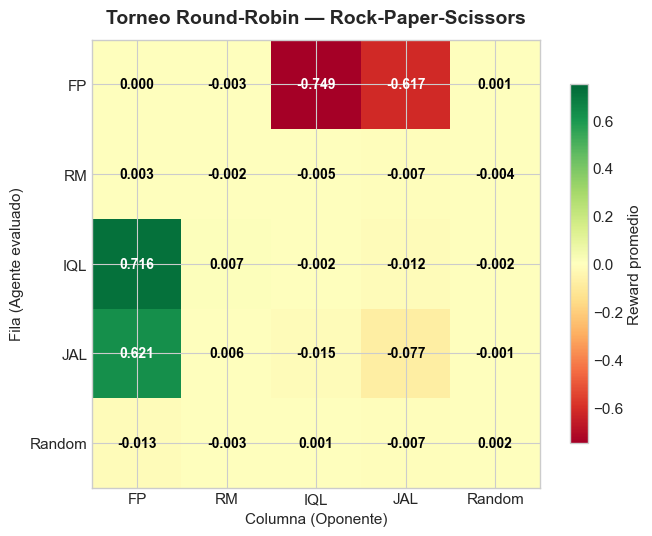

  Ranking en RPS:
    1.    Independent Q-Learning:   0.1413  █████████
    2.      JAL – Agent Modeling:   0.1067  █████████
    3.           Regret Matching:  -0.0030  ███████
    4.              Random Agent:  -0.0039  ███████
    5.           Fictitious Play:  -0.2736  ███



In [6]:
rps_m = run_tournament(RPS, AGENTS, n_episodes=N)
plot_tournament_heatmap(rps_m, AGENTS, 'Rock-Paper-Scissors')
print_ranking(rps_m, AGENTS, 'RPS')

### 2.1 Convergencia de Políticas en RPS
Veamos cómo evoluciona la distribución de probabilidad sobre las acciones a lo largo del entrenamiento para distintos enfrentamientos.

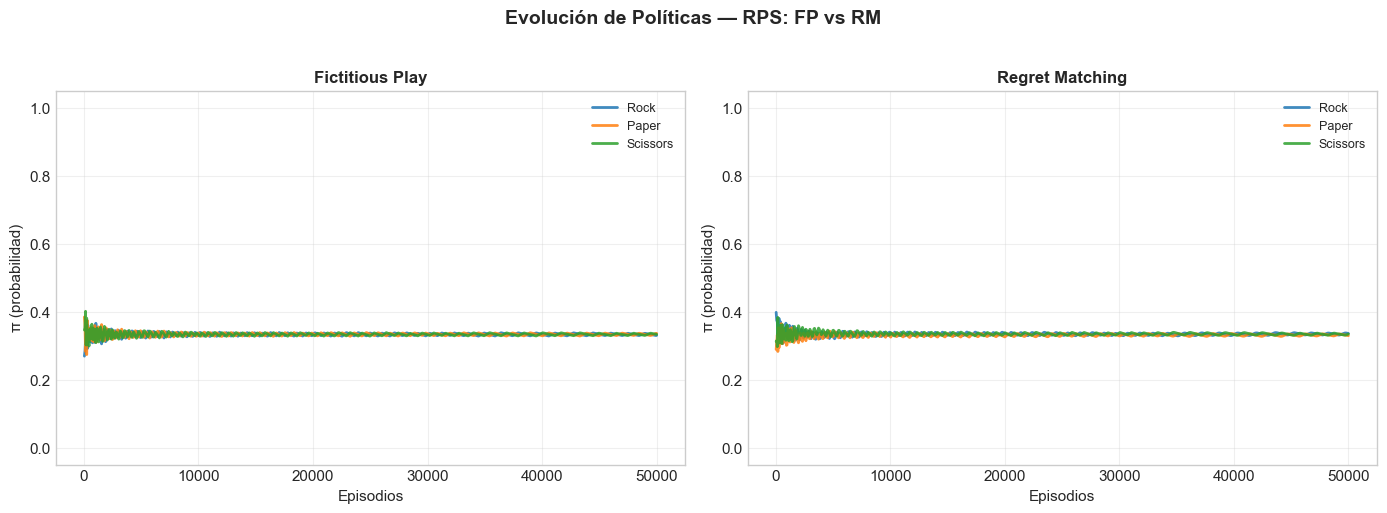

Políticas finales aprendidas:
            Fictitious Play:  [0.3304, 0.3362, 0.3334]
            Regret Matching:  [0.3361, 0.3296, 0.3344]



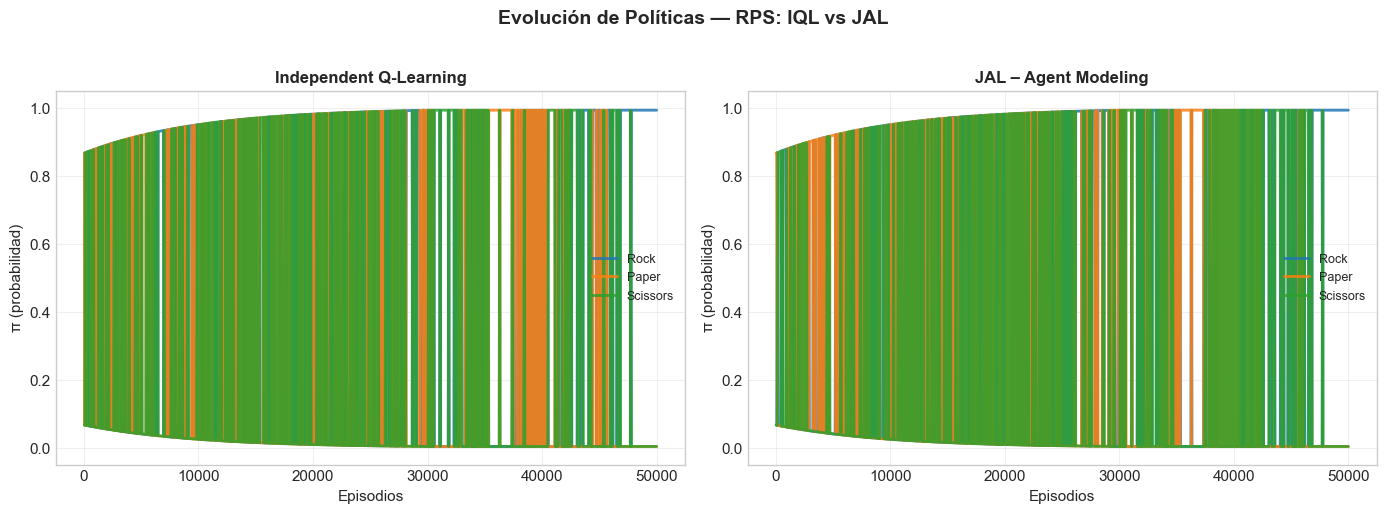

Políticas finales aprendidas:
     Independent Q-Learning:  [0.9933, 0.0033, 0.0033]
       JAL – Agent Modeling:  [0.9933, 0.0033, 0.0033]



In [13]:
L = ['Rock', 'Paper', 'Scissors']

r = run_experiment(RPS, ['FP', 'RM'], n_episodes=N, track_interval=50)
plot_policy_evolution(r, 'RPS', action_labels=L)
print_final_policies(r)

r = run_experiment(RPS, ['IQL', 'JAL'], n_episodes=N, track_interval=50)
plot_policy_evolution(r, 'RPS', action_labels=L)
print_final_policies(r)

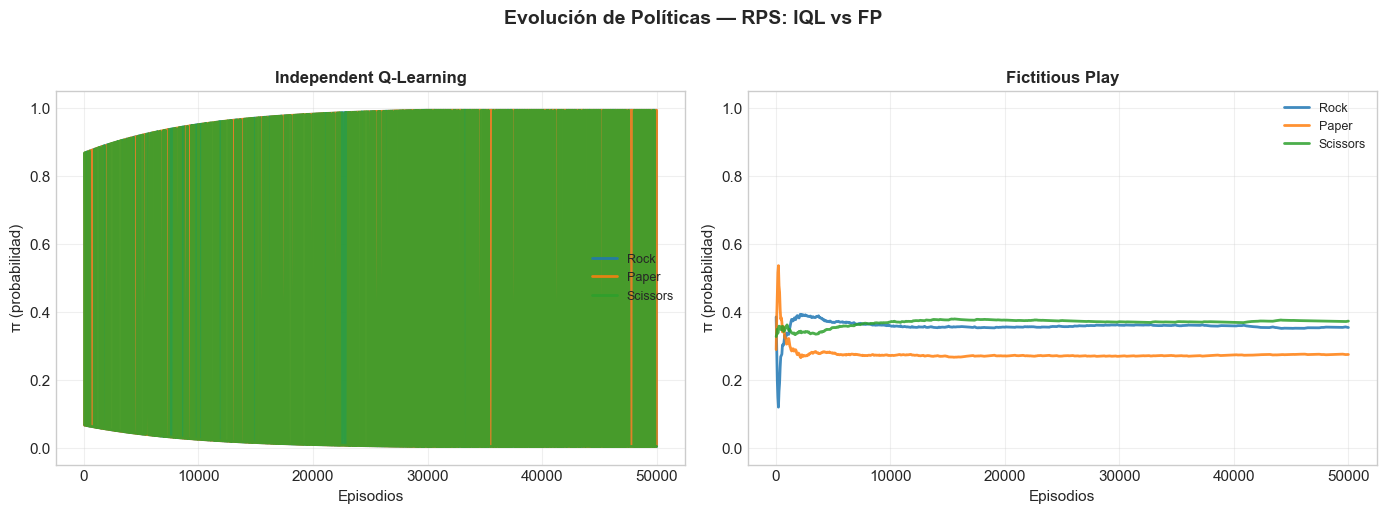

Políticas finales aprendidas:
     Independent Q-Learning:  [0.0033, 0.9933, 0.0033]
            Fictitious Play:  [0.3535, 0.2741, 0.3724]



In [14]:
r = run_experiment(RPS, ['IQL', 'FP'], n_episodes=N, track_interval=50)
plot_policy_evolution(r, 'RPS', action_labels=L)
print_final_policies(r)

### Análisis de Convergencia en Rock-Paper-Scissors

FP y RM funcionan como esperábamos: ambos convergen al equilibrio de Nash, jugando cada acción aproximadamente un tercio del tiempo (`[0.33, 0.34, 0.33]` y `[0.34, 0.33, 0.33]`). Al principio oscilan mientras se van "conociendo", pero se estabilizan rápido. La diferencia entre los dos es el mecanismo — FP mira qué juega el oponente y responde a eso, RM mira cuánto se arrepiente de sus propias jugadas — pero el resultado final es prácticamente idéntico.

IQL y JAL en cambio no convergen al equilibrio. Ambos colapsan a jugar **Rock** con 99% de probabilidad (`[0.9933, 0.0033, 0.0033]`). El problema de fondo es que estos algoritmos asumen que el entorno es estable mientras aprenden, pero en multiagente los dos están cambiando al mismo tiempo, lo que rompe esa suposición.

El heatmap del torneo deja claro el costo de esto: cuando FP enfrenta a IQL o JAL, **FP pierde fuerte** (-0.749 y -0.617). Lo que pasa es que IQL converge a Rock, FP lo modela y responde con Paper para explotarlo, pero IQL eventualmente reacciona y FP queda atrapado en un ciclo de adaptaciones donde termina perdiendo. RM no cae en esa trampa porque no modela al oponente — sus resultados contra IQL y JAL están cerca de cero, lo mismo que Random.

---
## 3. Matching Pennies (MP)

**Tipo:** Juego de suma cero simétrico · 2 acciones · **Nash:** π* = (½, ½) · **V* = 0**

| | Heads | Tails |
|---|:---:|:---:|
| **Heads** | 1, -1 | -1, 1 |
| **Tails** | -1, 1 | 1, -1 |


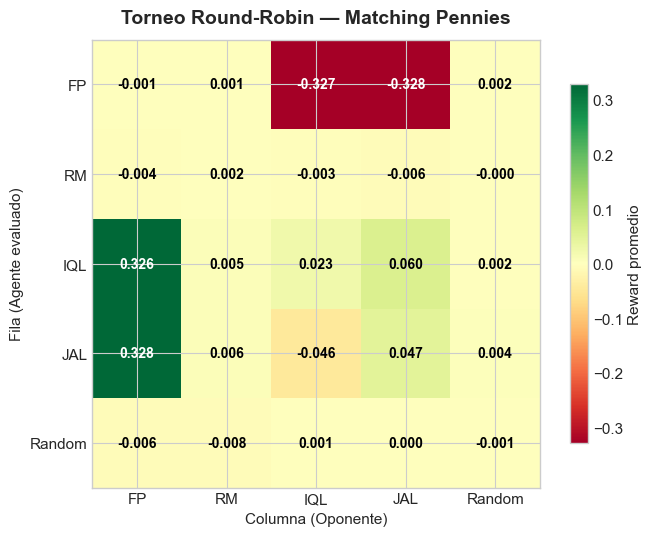

  Ranking en Matching Pennies:
    1.    Independent Q-Learning:   0.0833  ████████
    2.      JAL – Agent Modeling:   0.0680  ████████
    3.           Regret Matching:  -0.0023  ███████
    4.              Random Agent:  -0.0028  ███████
    5.           Fictitious Play:  -0.1307  █████



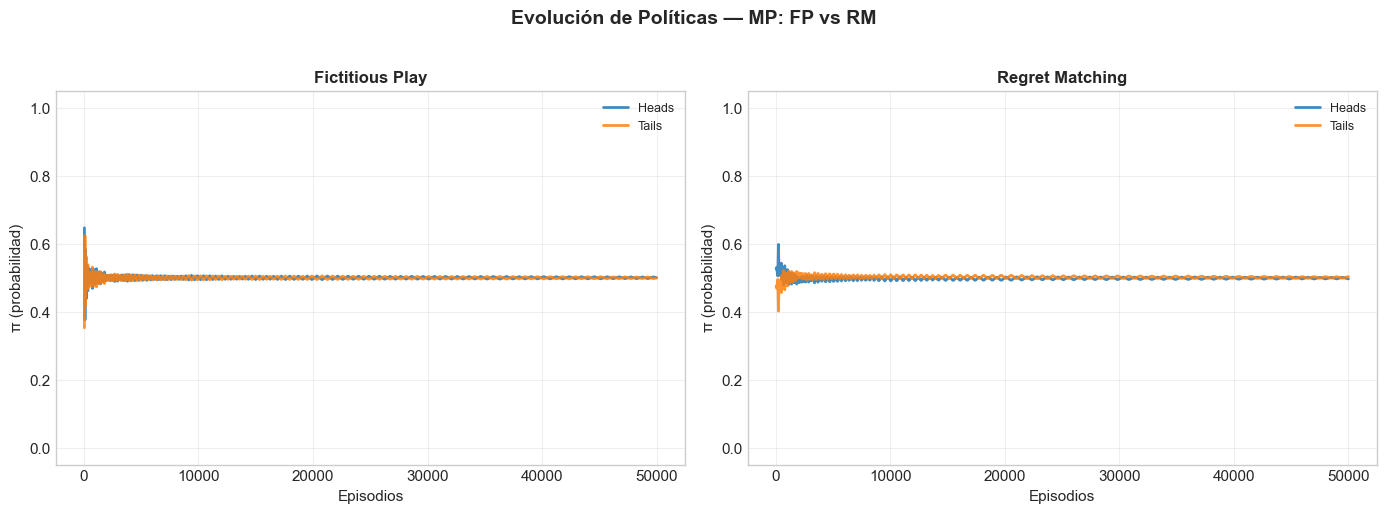

Políticas finales aprendidas:
            Fictitious Play:  [0.4999, 0.5001]
            Regret Matching:  [0.4966, 0.5034]



In [15]:
mp_m = run_tournament(MP, AGENTS, n_episodes=N)
plot_tournament_heatmap(mp_m, AGENTS, 'Matching Pennies')
print_ranking(mp_m, AGENTS, 'Matching Pennies')

r = run_experiment(MP, ['FP', 'RM'], n_episodes=N, track_interval=50)
plot_policy_evolution(r, 'MP', action_labels=['Heads', 'Tails'])
print_final_policies(r)

### Análisis de Convergencia en Matching Pennies

MP es otro juego de suma cero donde el equilibrio de Nash es jugar cada acción con 50% de probabilidad. FP y RM convergen a ese equilibrio sin sorpresas (`[0.50, 0.50]` ambos), igual que en RPS.

Lo más interesante acá aparece en el torneo. IQL y JAL le ganan consistentemente a FP (+0.326 y +0.328), mientras FP pierde fuerte contra ellos (-0.327 y -0.328). La explicación es la misma trampa que vimos en RPS: IQL y JAL colapsan a una acción casi determinista, FP los modela e intenta explotarlos, pero al hacerlo se vuelve predecible y termina siendo el explotado. RM no cae en eso — sus resultados contra IQL y JAL están cerca de cero, igual que Random — porque no modela al oponente y mantiene su política mixta estable.

El patrón se repite con más claridad que en RPS: **modelar al oponente cuando ese oponente colapsa a una estrategia determinista es una desventaja**, porque te hace predecible.

---
## 4. Blotto

**Tipo:** Juego de suma cero de asignación estratégica de recursos · Múltiples acciones combinatoriales.

Cada jugador distribuye S=3 soldados en N=2 frentes. Gana el frente quien asigna más soldados. El jugador que gane más frentes recibe +1, pierde -1, empata 0.


Torneo round-robin:   0%|          | 0/25 [00:00<?, ?it/s]

  Ranking en Blotto:
    1.           Regret Matching:   0.0821  ████████
    2.    Independent Q-Learning:   0.0276  ███████
    3.      JAL – Agent Modeling:   0.0266  ███████
    4.           Fictitious Play:   0.0142  ███████
    5.              Random Agent:  -0.1190  █████



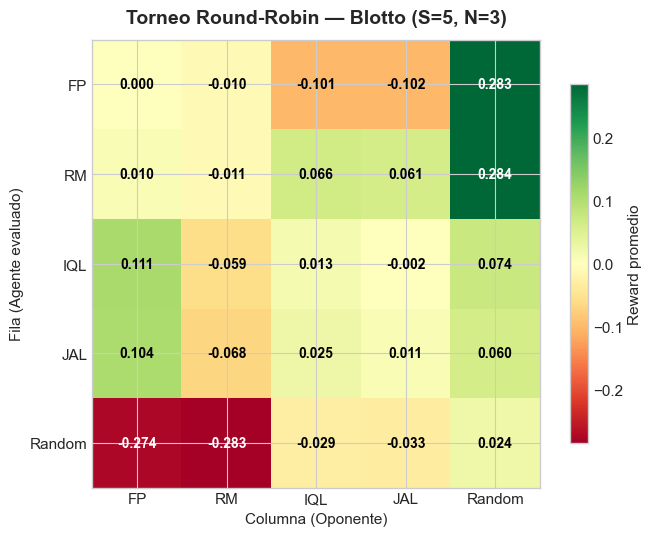

FP vs RM:   0%|          | 0/2000 [00:00<?, ?it/s]

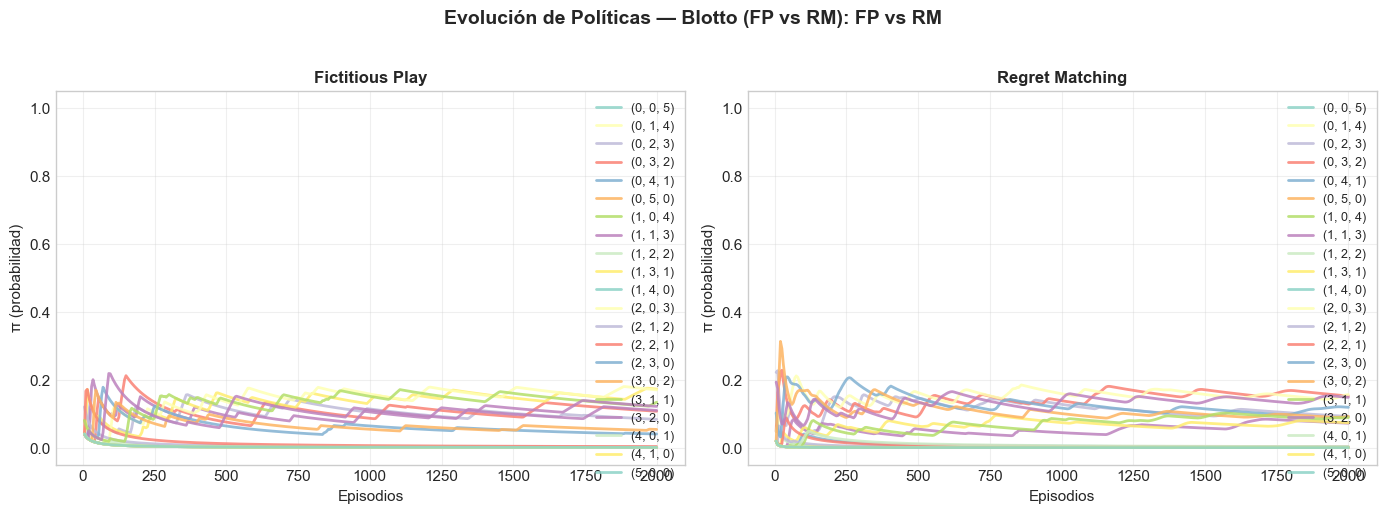

In [4]:
import importlib
import agents.fictitiousplay
import agents.regretmatching
importlib.reload(agents.fictitiousplay)
importlib.reload(agents.regretmatching)
from agents.fictitiousplay import FictitiousPlay
from agents.regretmatching import RegretMatching

blotto_m = run_tournament(Blotto_Original, AGENTS, n_episodes=2000, S=5, N=3)

print_ranking(blotto_m, AGENTS, "Blotto")
plot_tournament_heatmap(blotto_m, AGENTS, "Blotto (S=5, N=3)")

blotto_res = run_experiment(Blotto_Original, ['FP', 'RM'], n_episodes=2000, track_interval=5, S=5, N=3)

# Generar labels de las acciones para la gráfica (S=5, N=3)
dummy_game = Blotto_Original(S=5, N=3)
blotto_labels = [str(tuple(m)) for m in dummy_game._moves]

plot_policy_evolution(blotto_res, "Blotto (FP vs RM)", action_labels=blotto_labels)

### Análisis de Convergencia en Blotto

Blotto con 5 soldados y 3 frentes tiene 21 acciones posibles, lo que lo hace bastante más complejo que RPS o MP. Los resultados del torneo son claros: RM y FP dominan, con promedios positivos contra todos los oponentes, mientras que Random pierde fuerte contra ambos (-0.27 y -0.28).

Lo interesante de las gráficas de evolución es que FP y RM no convergen a una sola táctica sino que aprenden una **distribución sobre un subconjunto de tácticas efectivas**, dejando las acciones más débiles cerca de cero. Tiene sentido — en Blotto no hay una estrategia dominante pura, la mejor respuesta siempre depende de lo que haga el oponente.

IQL y JAL quedan en el medio: le ganan a Random pero no logran competir con FP y RM . Esto refleja la misma limitación que vimos en RPS y MP — Q-learning asume un entorno estacionario que en multiagente no se cumple — solo que en Blotto el problema se amplifica porque con 21 acciones el espacio de exploración es mucho más grande.

---
## 5. Battle of the Sexes (BoS)

**Tipo:** Juego de coordinación (suma NO cero) · 2 acciones.

| | Opera | Fútbol |
|---|:---:|:---:|
| **Opera** | 2, 1 | 0, 0 |
| **Fútbol** | 0, 0 | 1, 2 |

Tiene **dos equilibrios puros** (Opera, Opera) y (Fútbol, Fútbol), y un **equilibrio mixto** donde cada jugador mezcla de forma asimétrica.


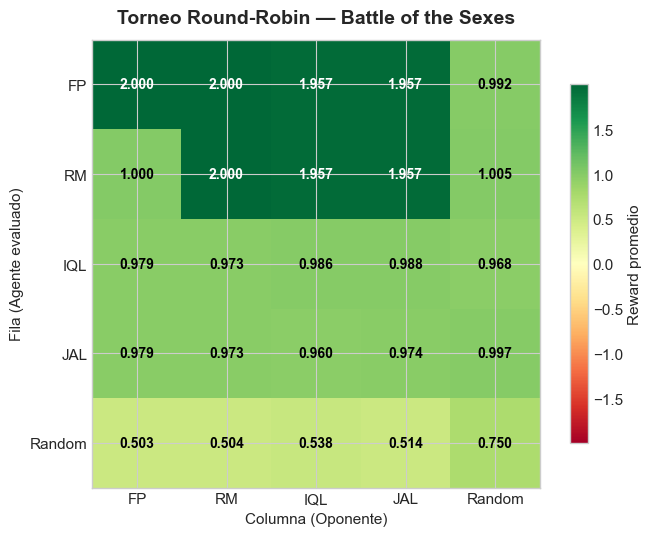

  Ranking en BoS:
    1.           Fictitious Play:   1.7811  ██████████████████████████████████
    2.           Regret Matching:   1.5836  ███████████████████████████████
    3.    Independent Q-Learning:   0.9789  ██████████████████████
    4.      JAL – Agent Modeling:   0.9767  ██████████████████████
    5.              Random Agent:   0.5616  ███████████████



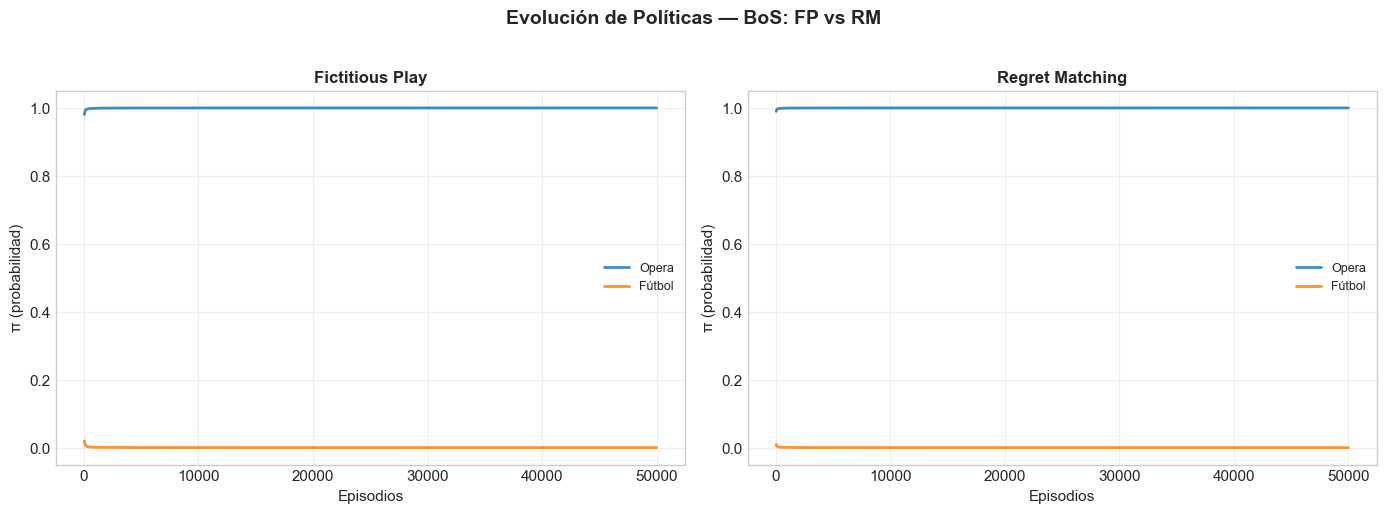

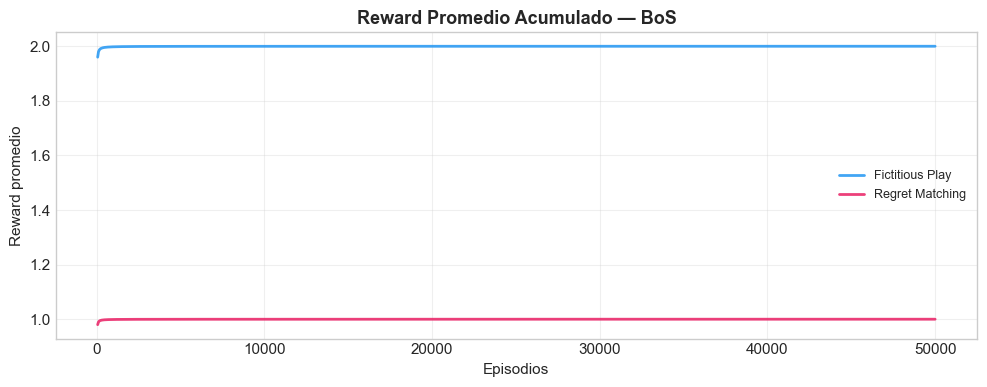

Políticas finales aprendidas:
            Fictitious Play:  [1.0000, 0.0000]
            Regret Matching:  [1.0000, 0.0000]



In [17]:
bos_m = run_tournament(BoS, AGENTS, n_episodes=N)
plot_tournament_heatmap(bos_m, AGENTS, 'Battle of the Sexes')
print_ranking(bos_m, AGENTS, 'BoS')

r = run_experiment(BoS, ['FP', 'RM'], n_episodes=N, track_interval=50)
plot_policy_evolution(r, 'BoS', action_labels=['Opera', 'Fútbol'])
plot_reward_evolution(r, 'BoS')
print_final_policies(r)

### Análisis de Convergencia en Battle of the Sexes

BoS es nuestro primer juego de coordinación y los resultados son claros. Tanto FP como RM convergen casi instantáneamente a un equilibrio puro. En este caso ambos eligen Opera desde el primer episodio y no se mueven de ahí.

El heatmap muestra algo interesante: FP vs RM da 2 y RM vs FP da 1. Esto no significa que FP sea mejor algoritmo — simplemente refleja que convergieron al equilibrio de Opera, donde el jugador 1 gana 2 y el jugador 2 gana 1. Si hubieran convergido a Fútbol sería al revés. El equilibrio al que llegan depende de la inicialización, no del algoritmo en sí.

IQL y JAL también coordinan en uno de los equilibrios puros, pero su reward (~0.98) es menor al máximo posible (~1.5 promedio en el equilibrio puro). La razón es la exploración residual del ε-greedy: aunque ε decae con el tiempo, nunca llega a cero, así que con cierta probabilidad siguen jugando acciones aleatorias y caen ocasionalmente en (Opera, Fútbol) o (Fútbol, Opera) donde ambos ganan 0.

Random es el que peor coordina, como era de esperar.

---
## 6. Chicken (Halcón-Paloma / L-S)

**Tipo:** Juego de anti-coordinación (suma NO cero) · 2 acciones (S, L).

| | S | L |
|---|:---:|:---:|
| **S** | 0, 0 | 7, 2 |
| **L** | 2, 7 | 6, 6 |

Es una variante del dilema del prisionero o Chicken con matriz ajustada. (L, L) da una recompensa moderada (6, 6). Sin embargo, si uno juega S y el otro L, el que juega S obtiene 7 y el que juega L obtiene 2. Si ambos juegan S, obtienen 0.

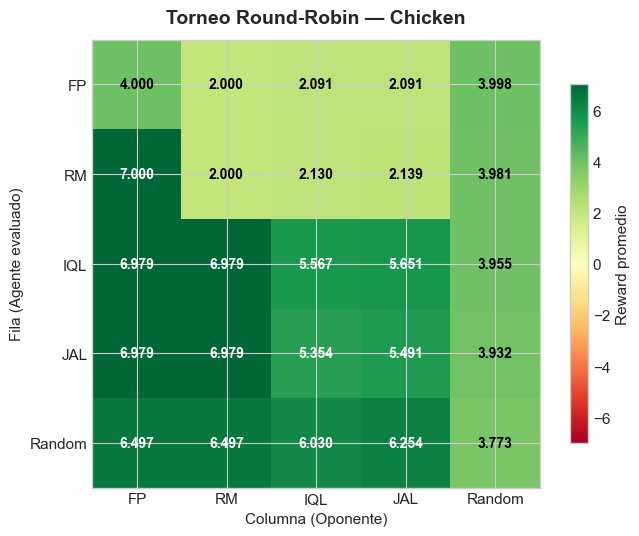

  Ranking en Chicken:
    1.    Independent Q-Learning:   5.8261  ██████████████████████████████████████████████████████████████████████████████████████████████
    2.              Random Agent:   5.8102  ██████████████████████████████████████████████████████████████████████████████████████████████
    3.      JAL – Agent Modeling:   5.7470  █████████████████████████████████████████████████████████████████████████████████████████████
    4.           Regret Matching:   3.4501  ███████████████████████████████████████████████████████████
    5.           Fictitious Play:   2.8359  ██████████████████████████████████████████████████



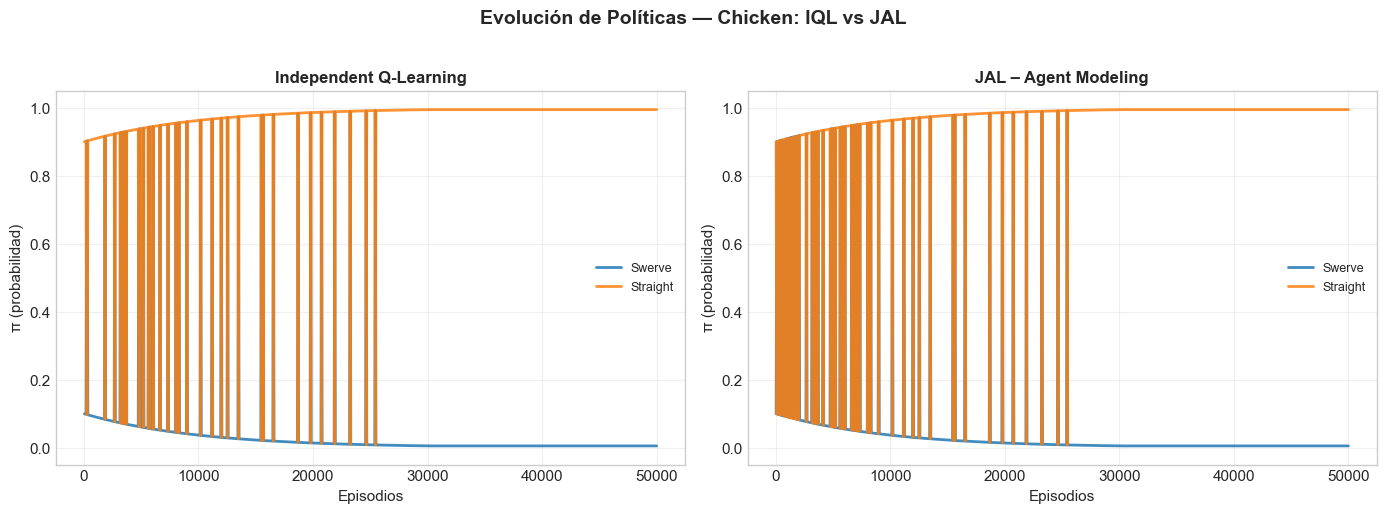

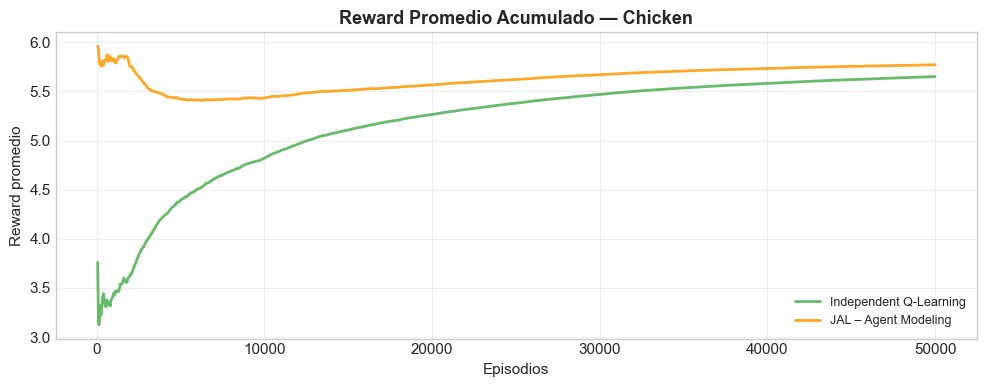

Políticas finales aprendidas:
     Independent Q-Learning:  [0.0050, 0.9950]
       JAL – Agent Modeling:  [0.0050, 0.9950]



In [18]:
ch_m = run_tournament(Chicken, AGENTS, n_episodes=N)
plot_tournament_heatmap(ch_m, AGENTS, 'Chicken')
print_ranking(ch_m, AGENTS, 'Chicken')

r = run_experiment(Chicken, ['IQL', 'JAL'], n_episodes=N, track_interval=50)
plot_policy_evolution(r, 'Chicken', action_labels=['Swerve', 'Straight'])
plot_reward_evolution(r, 'Chicken')
print_final_policies(r)

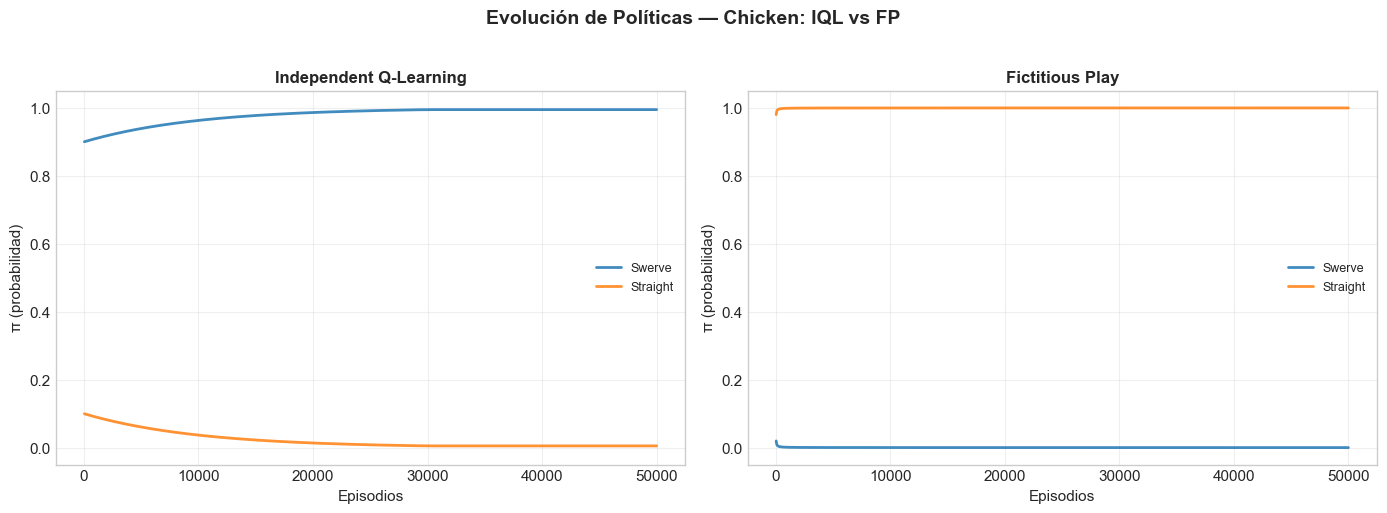

In [22]:
r = run_experiment(Chicken, ['IQL', 'FP'], n_episodes=N, track_interval=50)
plot_policy_evolution(r, 'Chicken', action_labels=['Swerve', 'Straight'])

### Análisis de Convergencia en Chicken

En Chicken IQL y JAL dominan el torneo con rewards promedio de 5.83 y 5.75, mientras que FP y RM quedan últimos con 2.84 y 3.45.

La clave está en cómo cada algoritmo reacciona al oponente, y lo más interesante es que IQL y JAL adoptan estrategias **diferentes según contra quién juegan**:

- **IQL/JAL vs FP/RM:** IQL y JAL convergen a Swerve (S). FP, que modela al oponente, ve que juega S y responde con Straight (L) — que en (L, S) le da al jugador fila solo 2 mientras el columna se lleva 7. IQL y JAL salen con ~7 puntos por matchup.

- **IQL vs JAL:** ambos convergen a Straight (L), cayendo en (L, L) = 6,6 que es el mejor resultado conjunto posible. El gráfico de reward acumulado muestra que JAL arranca con ventaja pero IQL lo alcanza a medida que ambos se estabilizan en este equilibrio.

Otro resultado interesante aparece en RM vs FP: RM saca 7 y FP saca 2. RM converge rápido a Swerve guiándose por sus regrets — Swerve le da el mayor arrepentimiento esperado en las primeras jugadas. FP detecta ese patrón y juega su best response (Straight), pero termina siendo el explotado porque (L, S) le da 2.

Random supera a FP y RM en el ranking (5.81 vs 2.84 y 3.45) porque al mezclar acciones cae en (L, L) = 6,6 con cierta frecuencia, mientras FP y RM quedan bloqueados respondiendo "racionalmente" a oponentes que ya tomaron la posición ventajosa.

---
## 7. Foraging (Level-Based Foraging)

**Tipo:** Juego estocástico cooperativo/competitivo en gridworld · Múltiples estados · Acciones: NONE, UP, DOWN, LEFT, RIGHT, LOAD.

En este ambiente, 2 agentes se mueven en una grilla 5×5 buscando comida. Para recoger la comida necesitan estar en la celda correcta y ejecutar LOAD. La recompensa se otorga al recolectar exitosamente.

> A diferencia de los juegos matriciales anteriores (1 estado), Foraging tiene **múltiples estados** y **episodios con horizonte finito**. Solo IQL y JAL-AM están diseñados para esto, ya que mantienen tablas Q indexadas por estado.

In [19]:
import importlib
import agents.jal
importlib.reload(agents.jal)
from agents.jal import JAL

import lbforaging
from games.foraging import Foraging

def run_foraging_experiment(config, agent_name, n_episodes=2000, seed=42):
    """Entrena agentes IQL o JAL en el ambiente Foraging y retorna rewards totales por episodio."""
    episode_rewards = []
    
    game = Foraging(config=config, seed=seed)
    
    agents_dict = {}
    for ag in game.agents:
        if agent_name == 'IQL':
            agents_dict[ag] = IQL(game=game, agent=ag, alpha=0.1, epsilon=0.3,
                            min_epsilon=0.05, epsilon_decay=0.999, gamma=0.95, seed=seed)
        elif agent_name == 'JAL':
            agents_dict[ag] = JAL(game=game, agent=ag, alpha=0.1, epsilon=0.3,
                            min_epsilon=0.05, epsilon_decay=0.999, gamma=0.95, seed=seed)
        else:
            agents_dict[ag] = RandomAgent(game=game, agent=ag)
    
    for ep in tqdm(range(n_episodes), desc=f'{agent_name} - {config}', leave=False):
        game.reset()
        for ag in game.agents:
            if hasattr(agents_dict[ag], 'reset'):
                agents_dict[ag].reset()
        
        ep_reward = {ag: 0.0 for ag in game.agents}
        
        while not game.done():
            actions = {ag: agents_dict[ag].action() for ag in game.agents}
            game.step(actions)
            for ag in game.agents:
                ep_reward[ag] += game.reward(ag)
                # Pass actions to JAL so it knows what opponents played
                if hasattr(agents_dict[ag], 'set_last_actions'):
                    agents_dict[ag].set_last_actions(actions)
                if hasattr(agents_dict[ag], 'update'):
                    agents_dict[ag].update()
        
        total_ep = sum(ep_reward.values())
        episode_rewards.append(total_ep)
    
    return episode_rewards

print('✅ Funciones de Foraging definidas (JAL reloaded)')

✅ Funciones de Foraging definidas (JAL reloaded)


### 7.1 Entrenamiento IQL vs JAL-AM vs Random en Foraging 5×5

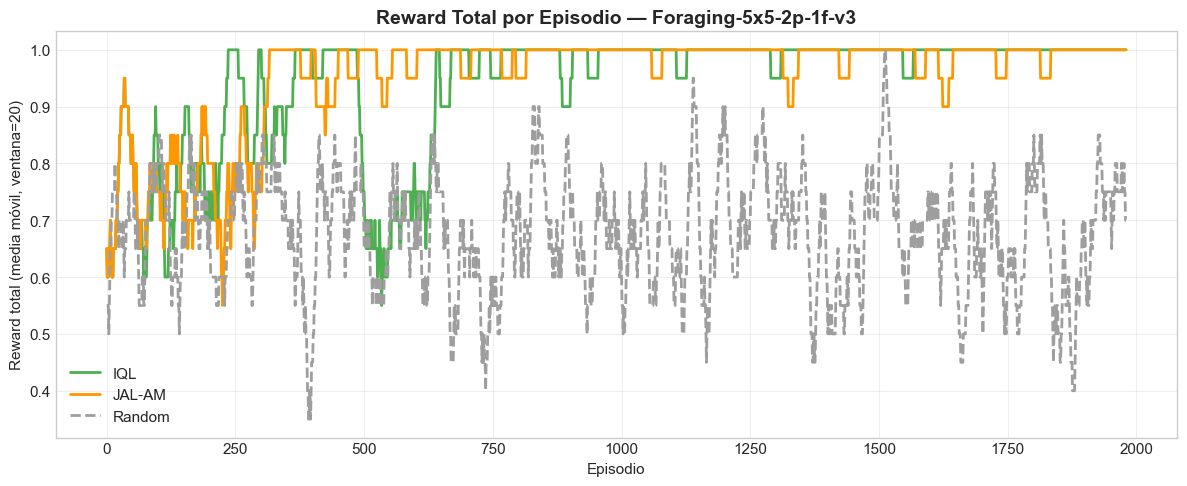

Reward promedio (últimos 50 episodios):
  IQL:    1.000
  JAL-AM: 1.000
  Random: 0.720


In [20]:
config = "Foraging-5x5-2p-1f-v3"
n_ep = 2000

import warnings
warnings.filterwarnings('ignore')

iql_rewards = run_foraging_experiment(config, 'IQL', n_episodes=n_ep)
jal_rewards = run_foraging_experiment(config, 'JAL', n_episodes=n_ep)
rnd_rewards = run_foraging_experiment(config, 'Random', n_episodes=n_ep)

def smooth(data, window=20):
    return np.convolve(data, np.ones(window)/window, mode='valid')

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(smooth(iql_rewards), label='IQL', color=AGENT_COLORS['IQL'], linewidth=2)
ax.plot(smooth(jal_rewards), label='JAL-AM', color=AGENT_COLORS['JAL'], linewidth=2)
ax.plot(smooth(rnd_rewards), label='Random', color=AGENT_COLORS['Random'], linewidth=2, linestyle='--')

ax.set_title(f'Reward Total por Episodio — {config}', fontsize=14, fontweight='bold')
ax.set_xlabel('Episodio')
ax.set_ylabel('Reward total (media móvil, ventana=20)')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Reward promedio (últimos 50 episodios):")
print(f"  IQL:    {np.mean(iql_rewards[-50:]):.3f}")
print(f"  JAL-AM: {np.mean(jal_rewards[-50:]):.3f}")
print(f"  Random: {np.mean(rnd_rewards[-50:]):.3f}")

### Análisis de Convergencia en Foraging

Foraging es el único ambiente con múltiples estados y episodios secuenciales, donde los agentes deben navegar una grilla 5x5 para recoger comida. A diferencia de los juegos matriciales, acá las acciones pasadas afectan el estado futuro, lo que hace que Q-learning tenga sentido.

Con 2000 episodios de entrenamiento, **IQL y JAL alcanzan el reward máximo de 1.0** en los últimos 50 episodios, mientras que Random se queda en 0.72. Ambos aprenden a coordinarse para recoger la comida de forma óptima.

El gráfico muestra que el aprendizaje es bastante similar entre los dos: ambos suben rápido en los primeros 500 episodios y se estabilizan cerca del máximo a partir de los 1000 episodios. La varianza inicial refleja la exploración propia del ε-greedy, pero una vez que ε decae a su mínimo, las políticas se estabilizan.

Lo importante de este resultado es que confirma que IQL y JAL **sí funcionan bien en su ambiente natural** — juegos con estados, episodios secuenciales y cooperación. Los problemas que vimos en RPS, MP y Chicken no son del algoritmo en sí, sino de aplicarlo fuera de su contexto adecuado.

---
## 8. Tabla Comparativa Consolidada

Resumen de los resultados de todos los torneos round-robin, mostrando el reward promedio de cada algoritmo en cada juego.

In [24]:
import pandas as pd

games = ['RPS', 'MP', 'Blotto', 'BoS', 'Chicken']
matrices = [rps_m, mp_m, blotto_m, bos_m, ch_m]

consolidated = {}
for agent_idx, agent in enumerate(AGENTS):
    consolidated[agent] = {}
    for game_name, matrix in zip(games, matrices):
        row = matrix[agent_idx]
        avg_reward = np.mean(row)
        consolidated[agent][game_name] = round(avg_reward, 3)

df = pd.DataFrame(consolidated).T
df.index.name = 'Agente'

print("=" * 60)
print("  TABLA COMPARATIVA — Reward Promedio por Juego")
print("=" * 60)
print(df.to_string())
print("=" * 60)

  TABLA COMPARATIVA — Reward Promedio por Juego
          RPS     MP  Blotto    BoS  Chicken
Agente                                      
FP     -0.275 -0.131   0.013  1.781    2.836
RM     -0.001 -0.002   0.080  1.584    3.450
IQL     0.141  0.083   0.021  0.979    5.826
JAL     0.106  0.068   0.024  0.977    5.747
Random -0.004 -0.003  -0.127  0.562    5.810


---
## 9. Conclusiones

Tras correr los experimentos, logramos comprobar algunas de las cosas vistas en clase.

**FP y RM** son los algoritmos más sólidos en juegos matriciales. Convergen al equilibrio de Nash en juegos de suma cero (RPS, MP, Blotto) y coordinan rápidamente en juegos de coordinación pura (BoS), donde ambos alcanzan rewards cercanos al máximo posible. Si bien tienen mecanismos distintos — FP modela al oponente, RM minimiza su propio arrepentimiento — obtienen resultados muy similares. Su debilidad aparece en Chicken, donde ser predecibles los convierte en víctimas de agentes que colapsan a una estrategia fija.

**IQL y JAL** no son los algoritmos indicados para juegos matriciales de una sola jugada. Su naturaleza de Q-learning asume un entorno estacionario que en sistemas multiagente no se cumple, lo que se traduce en que colapsan a políticas casi deterministas que no representan el equilibrio teórico. En cambio, en Foraging demuestran su valor real: ambos alcanzan el reward máximo de 1.0 contra el 0.72 de Random, confirmando que sí funcionan bien en ambientes con estados y episodios secuenciales, su contexto natural.

Para nosotros, el resultado más inesperado del obligatorio fue Chicken: IQL y JAL dominaron el torneo (5.83 y 5.75) no por aprender mejor sino por colapsar a una estrategia determinista que FP y RM intentaron explotar racionalmente — pero terminaron siendo los explotados. Incluso Random superó a FP y RM en este juego, lo que muestra que en ciertos contextos "razonar sobre el oponente" puede ser una desventaja frente a estrategias más simples pero firmes.